## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds, get_GHG
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenario and modules

Set path to folders containing all default and scenario data. Select the 'baseline' scenario, define years to calculate output for and create a container to store outputs per year. To save time we use 10-year time steps, but 1-year time steps are also possible.

In [3]:
# Set paths to default and scenario data
cm.ParameterRetriever.set_data_folders(
    default = os.path.join('..','data','prod_parameters'),
    scenarios = os.path.join('..','data','scenarios')
)

# Define scenario, years and create output container
scn = 'none'
year = '2020'
output = pd.DataFrame(
    columns=['dem','crp','ani'],
    index=pd.MultiIndex.from_frame(pd.DataFrame({'scn':[scn],'year':[year]}))
)

In [4]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.x0_crops.index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever('ManureMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    crops = crops,
    herds = herds,
    demand = demand,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

In [5]:
# Get region attributes
regions.calculate(verbose=True)

# Calculate food demand
demand.calculate(verbose=True)

# Calculate crops
crops.calculate(
    verbose = True
)

# Calculate herds
for h in herds:
    h.calculate(verbose = True)

# Calculate feed
feed_mgmt.calculate(verbose=True)    

# Adjust animal demand to stat (CHECK DEMAND DATA TO ALIGN!!!)
demand.animal_prod_demand.update(
    pd.Series(
        {
            ('conventional','cattle','meat') : (136-21) * 1000000,
            ('organic','cattle','meat')      : 21 * 1000000,
            ('conventional','cattle','milk') : (2760-464) * 1000000,
            ('organic','cattle','milk')      : 464 * 1000000,
            ('conventional','pigs','meat')   : (249-6) * 1000000,
            ('organic','pigs','meat')        : 6 * 1000000,
            ('conventional','poultry','meat')   : (152-0) * 1000000,
            ('organic','poultry','meat')        : 0 * 1000000,
        },
    )
    .rename('food')
    .rename_axis(['prod_system','species','animal_prod'])
)

# Distribute animals and crops
# Make optimisation problem
geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.6, verbose=True)
# Solve optimisation problem
geodist.solve(
    verbose=True,
    solver_settings = {
        'solver':'OSQP',
        'max_iter':200000,
        'eps_abs':5e-6,
        'eps_rel':5e-6,
        'verbose':False
    }
)

# Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
feed_mgmt.calculate2(verbose=True)

# Calculate manure
manure_mgmt.calculate(verbose=True)

# Calculate plant nutrient management
plant_nutrient_mgmt.calculate(verbose=True)

# Calculate energy requirements
machinery_and_energy_mgmt.calculate(verbose=True)

# Store results
# Demand
output.loc[(scn,year),'dem'] = \
demand.make_static()
# Crops
output.loc[(scn,year),'crp'] = \
crops.make_static()
# Animals
output.loc[(scn,year),'ani'] = \
concat_herds(
    herds.apply(lambda x: x.make_static())
)

[09:38:40][Regions] Getting initial crop areas and animal numbers (x0) ...
[09:38:40][Regions] Getting climate and soil attributes ...
[09:38:40][Regions] Done! Elapsed time: 0 sec
[09:38:40][DemandAndConversions] Calculating food demand ...
[09:38:40][DemandAndConversions] Calculating waste ...
[09:38:40][DemandAndConversions] Calculating crop product demand ...
[09:38:40][DemandAndConversions] Calculating animal product demand ...
[09:38:41][DemandAndConversions] Done! Elapsed time: 1 sec
[09:38:41][CropProduction] Calculating harvest ...
[09:38:41][CropProduction] Calculating production ...
[09:38:43][CropProduction] Calculating crop residues ...
[09:38:44][CropProduction] Calculating seed demand ...
[09:38:45][CropProduction] Done! Elapsed time: 4 sec
[09:38:45][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[09:38:45][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[09:38:45][AnimalHerd (cattle, beef, conventional, none)] Do

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:163: PerformanceWarning: indexing past lexsort depth may impact performance.
  x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:163: PerformanceWarning: indexing past lexsort depth may impact performance.
  x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:163: PerformanceWarning: indexing past lexsort depth may impact performance.
  x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],


[09:40:09][GeoDistributor.solve] Done! Elapsed time: 28 sec
[09:40:09][FeedMgmt] Adjusting feed rations (not implemented) ...
[09:40:09][FeedMgmt] Calculating enteric methane emissions ...
[09:40:11][FeedMgmt] Done! Elapsed time: 2 sec
[09:40:11][ManureMgmt] Calculating VS excretion ...
[09:40:14][ManureMgmt] Calculating VS losses ...
[09:40:16][ManureMgmt] Calculating N excretion ...
[09:40:18][ManureMgmt] Calculating N losses ...
[09:40:36][ManureMgmt] Calculating N available to spread ...
[09:40:38][ManureMgmt] Done! Elapsed time: 26 sec
[09:40:38][PlantNutrientMgmt] Calculating crop N requirements ...
[09:40:40][PlantNutrientMgmt] Distributing manure ...
[09:40:43][PlantNutrientMgmt] Calculating mineral N application ...
[09:40:43][PlantNutrientMgmt] Calculating N in crop residues ...
[09:40:43][PlantNutrientMgmt] Calculating N application losses ...
[09:40:43][PlantNutrientMgmt] Calculating N soil losses ...
[09:40:44][PlantNutrientMgmt] Done! Elapsed time: 6 sec
[09:40:44][Machin

## WIP fix animal demand

In [27]:
demand.par = cm.ParameterRetriever('DemandAndConversions')
demand.calculate()

In [28]:
stat = pd.Series(
    {
        ('conventional','cattle','meat') : (136-21),
        ('organic','cattle','meat')      : 21,
        ('conventional','cattle','milk') : (2760-464),
        ('organic','cattle','milk')      : 464,
        ('conventional','pigs','meat')   : (249-6),
        ('organic','pigs','meat')        : 6,
        ('conventional','poultry','meat')   : (152-0),
        ('organic','poultry','meat')        : 0,
    },
).sort_index().rename_axis(['prod_system','species','animal_prod'])

In [29]:
(demand.animal_prod_demand['food']/1000000 - stat)/(demand.animal_prod_demand['food']/1000000)*100

prod_system   species  animal_prod
conventional  cattle   meat            9.141651
                       milk          -11.873278
              horses   heads                NaN
              pigs     meat           -1.927860
              poultry  meat           20.900105
organic       cattle   meat            8.854352
                       milk          -10.382857
              pigs     meat           -2.347316
              poultry  meat                 NaN
dtype: float64

In [24]:
stat

prod_system   species  animal_prod
conventional  cattle   meat            115
                       milk           2296
              pigs     meat            243
              poultry  meat            152
organic       cattle   meat             21
                       milk            464
              pigs     meat              6
              poultry  meat              0
dtype: int64

In [23]:
demand.animal_prod_demand['food']/1000000

prod_system   species  animal_prod
conventional  cattle   meat            126.570647
                       milk           2052.322091
              horses   heads             0.000000
              pigs     meat            238.403906
              poultry  meat            192.162076
organic       cattle   meat             23.040047
                       milk            420.355127
              pigs     meat              5.862391
              poultry  meat              0.000000
Name: food, dtype: float64

# Check solution

### GHG emissions compared to NIR

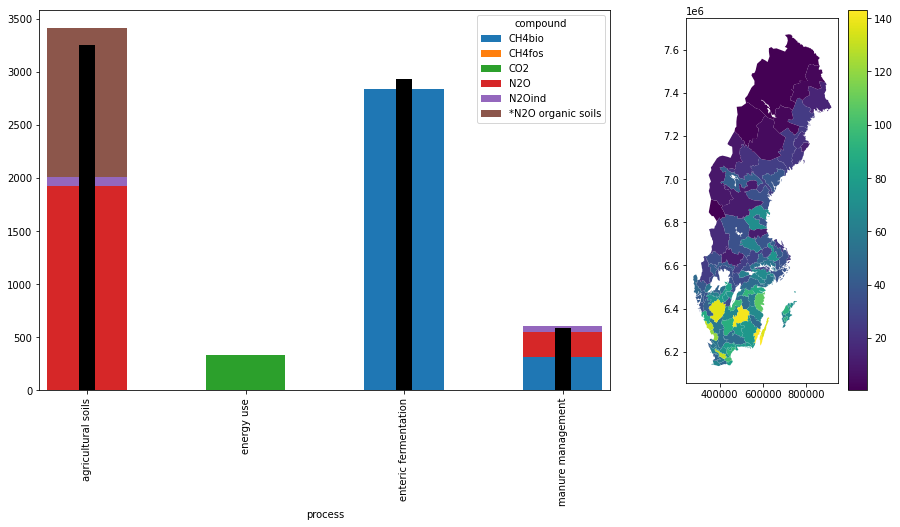

In [8]:
plot_data = (
    get_GHG(output)
    .sum()
    .groupby(['process','compound'])
    .sum()
    .unstack()
    /1000000
)
# Add missing emissions
plot_data.loc['agricultural soils','*N2O organic soils'] = \
(230200 * 13 * (44/28) * 298)/1000000

# plot_data.loc['manure management','*CH4 manure mgmt'] = \
# 590 * 0.45

plot_data_NIR = pd.Series(
    [3250,0,2930,590],
    index=pd.Index(['agricultural soils','energy use','enteric fermentation','manure management'], name='process')
)

# Bar plot
fig, axs = plt.subplots(1,2, figsize=(15,7), gridspec_kw={'width_ratios': [3, 1]})
plot_data.plot.bar(stacked='True', ax=axs[0])
plot_data_NIR.plot.bar(stacked='True', ax=axs[0], width=0.1, color='black')

#
plot_data = (
    get_GHG(output)
    .sum(axis=1)
    /1000000
)

plot.map_from_series(plot_data, ax=axs[1])

plt.show()

### Check deviations from x0

In [34]:
print('Crops max(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).max())
print('Crops min(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).min())
print('Animals max(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).max())
print('Animals min(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).min())

Crops max(x-x0) [ha]: 10312.020331275442
Crops min(x-x0) [ha]: -11428.255069154578
Animals max(x-x0) [nr]: 3102.5902336512067
Animals min(x-x0) [nr]: -22741.726479732664


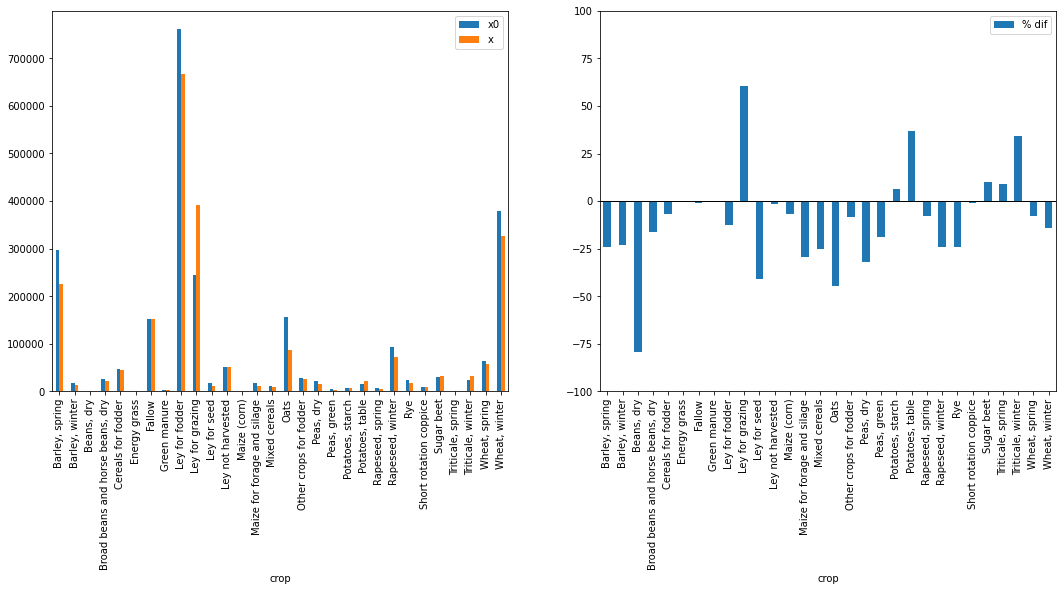

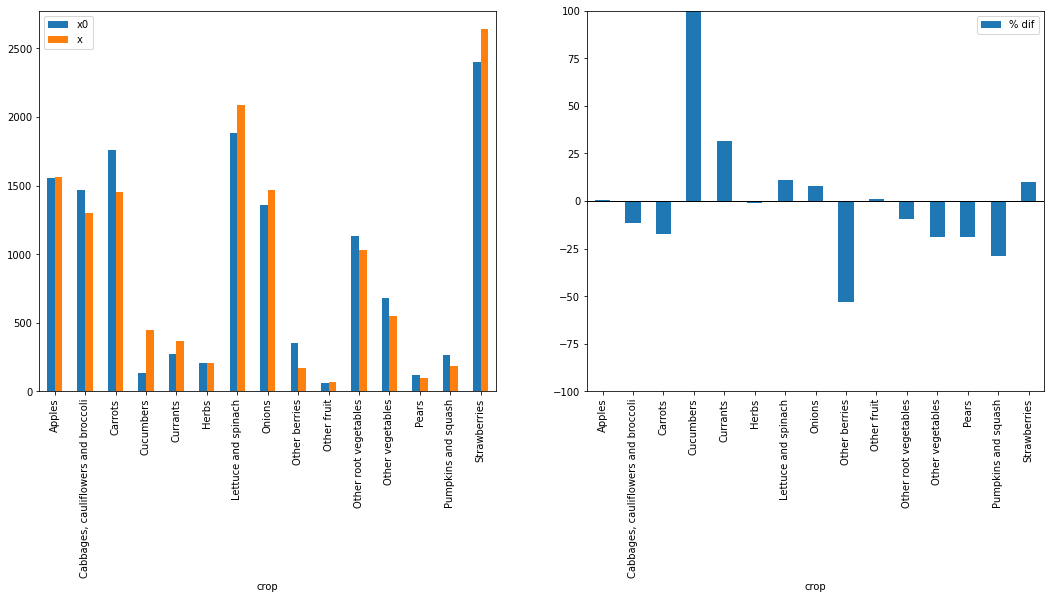

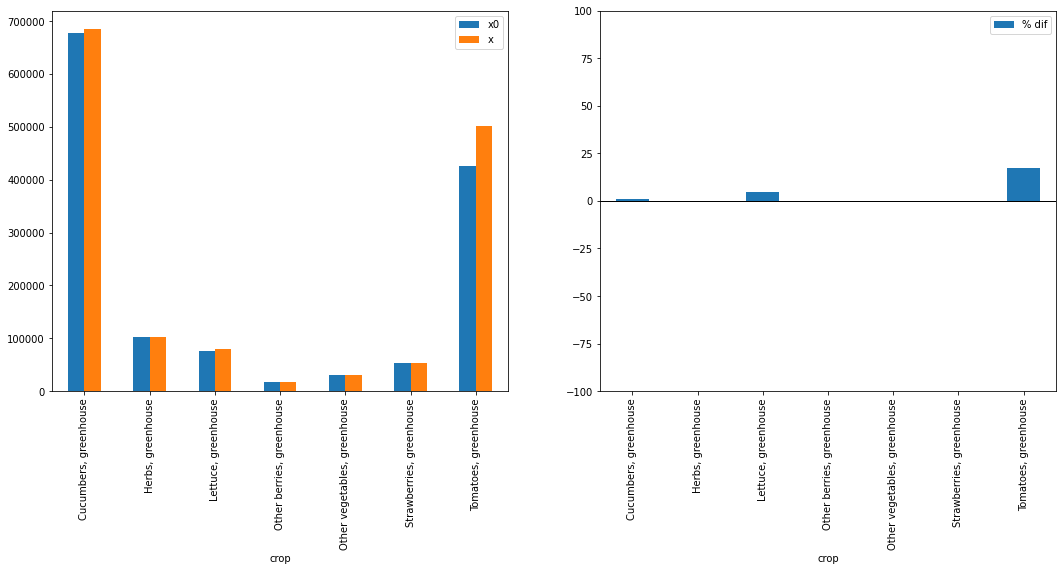

In [43]:
plot_data = (
    pd.concat([
        output.loc[('none','2020'),'crp'].area.groupby('crop').sum().rename('x'),
        geodist.x0['crp'].groupby('crop').sum().rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [
                x['x'],
                x['x0'],
                ((x['x']-x['x0'])/x['x0']*100)
            ],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

cg_dict = crops.par.get_rel('crop','crop_group')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables','Berries','Fruit trees']
gh = ['Vegetables, greenhouse','Berries, greenhouse']
sng = ['Semi-natural grasslands']

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[~plot_data['cg'].isin(hr+gh+sng)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[~plot_data['cg'].isin(hr+gh+sng)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[plot_data['cg'].isin(hr)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[plot_data['cg'].isin(hr)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[plot_data['cg'].isin(gh)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[plot_data['cg'].isin(gh)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

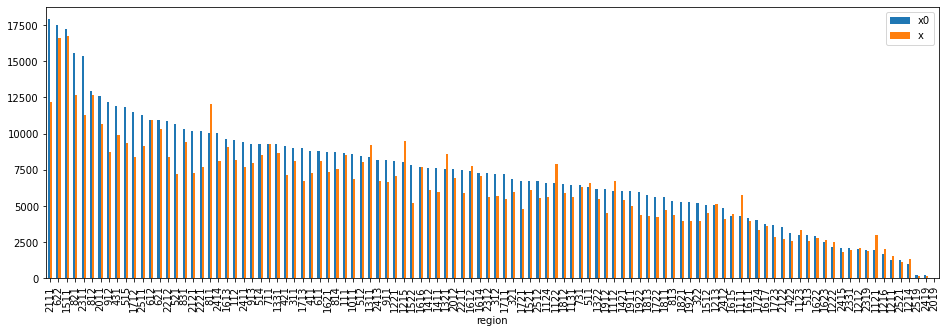

In [82]:
crp = 'Ley for fodder'

fig, ax = plt.subplots(figsize=(16,5))

pd.concat([
    geodist.x0['crp'].xs(crp, level='crop').groupby('region').sum().rename('x0'),
    output.loc[('none','2020'),'crp'].area.xs(crp, level='crop').groupby('region').sum().rename('x')
], axis=1).sort_values('x0', ascending=False).plot.bar(ax=ax)

plt.show()

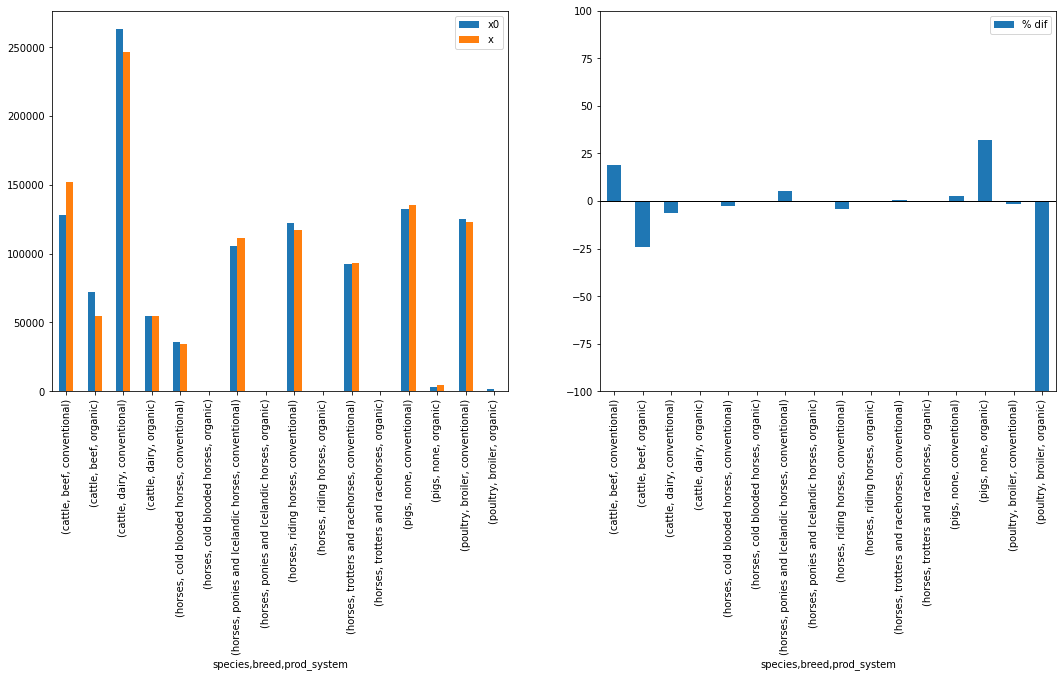

In [81]:
idx = pd.IndexSlice

plot_data = (
    pd.concat([
        output.loc[('none','2020'),'ani'].heads
        .loc[:,idx[:,:,:,:,[
            'cows','sows','gilts','broodmares','low-performing horses',
            'medium-performing horses','young horses','broilers'
        ]]]
        .groupby(['species','breed','prod_system'], axis=1).sum()
        .sum()
        .rename('x')
        ,
        geodist.x0['ani']
        .groupby(['species','breed','prod_system']).sum()
        .rename('x0')
    ], axis=1)
)
# Adjust poultry to 100 heads
plot_data = \
plot_data.mul(np.where(plot_data.index.get_level_values('species')=='poultry',1/100,1), axis=0)
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data.plot.bar(y=['x0','x'], ax=axs[0])
plot_data.plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

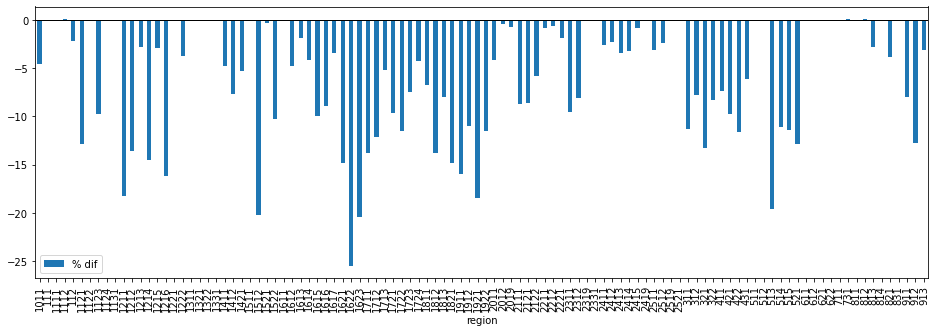

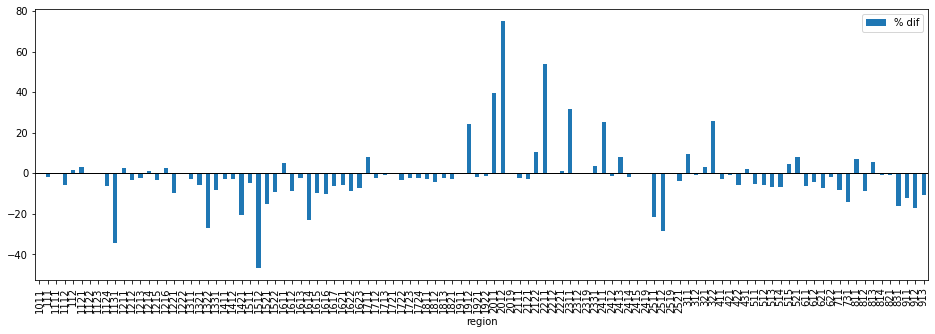

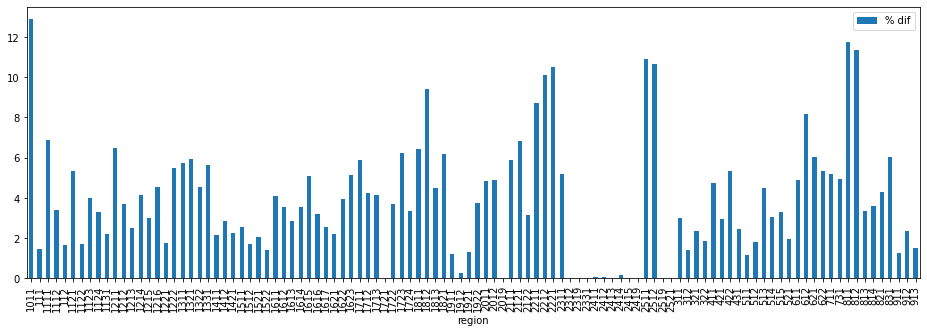

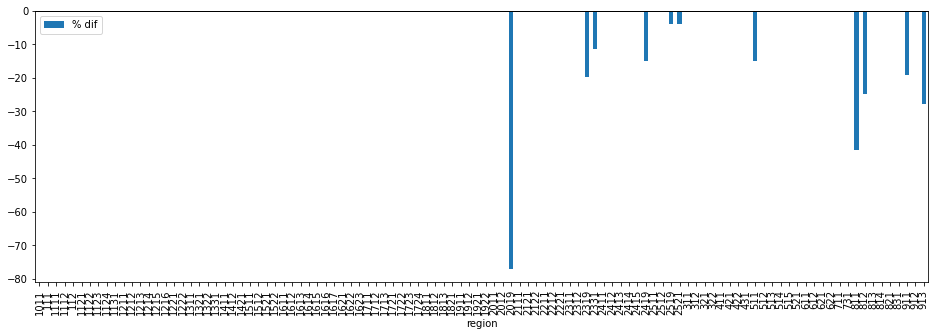

In [110]:

plot_data_ = (pd.concat([
    output.loc[('none','2020'),'crp'].area.groupby(['crop','region']).sum().rename('x'),
    geodist.x0['crp'].groupby(['crop','region']).sum().rename('x0')
], axis=1)
)

cg_dict = crops.par.get_rel('crop','crop_group')
plot_data_['cg'] = [cg_dict[c] for c in plot_data_.index.get_level_values('crop')]

hr = ['Vegetables','Berries','Fruit trees']
gh = ['Vegetables, greenhouse','Berries, greenhouse']
sng = ['Semi-natural grasslands']

# Crops
plot_data = plot_data_.loc[~plot_data_['cg'].isin(hr+gh+sng)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.show()

# Horti
plot_data = plot_data_.loc[plot_data_['cg'].isin(hr)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.show()

# Greenhouse
plot_data = plot_data_.loc[plot_data_['cg'].isin(gh)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.show()

# Semi-natural grasslands
plot_data = plot_data_.loc[plot_data_['cg'].isin(sng)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.show()